In [1]:
import os
import sys


import optax
import equinox as eqx
import esm
import esm2quinox
import jax.random as jr

import jax.numpy as jnp
import numpy as np
import torch
from model_equinox import jax_predictor
from model_torch import StrippedPredictor
from transformers import AutoModel
import pandas as pd
import jax



sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from torch.utils.data import DataLoader

from transformers import AutoTokenizer
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns


base_path = '/home/kunzj'


In [2]:

def check_torch_vs_jax_weights(model_torch, model_jax, rtol=np.NaN, atol=np.NaN):
    """
    Compares PyTorch and Equinox model weights and biases.
    
    Args:
        model_torch: PyTorch model
        model_jax: Equinox model
        rtol: relative tolerance
        atol: absolute tolerance
    
    Returns:
        True if all weights and biases match, False otherwise
    """
    import numpy as np

    all_close = True
    mismatches = []

    # -------- Compare ESM2 self attention layers --------
    for prefix in ['prot', 'pept']:
        torch_esm = getattr(model_torch, f"esm2_{prefix}")
        jax_esm = getattr(model_jax, f"esm2_{prefix}")
        for i in range(30):
            # attention projections
            for proj_name in ["query", "key", "value"]:
                # Torch linear module for this projection
                torch_linear = getattr(torch_esm.encoder.layer[i].attention.self, proj_name)
                torch_w = torch_linear.weight.detach().cpu().numpy()
                torch_b = torch_linear.bias.detach().cpu().numpy()

                # JAX/Equinox projection (names use *_proj)
                jax_proj = getattr(jax_esm.layers.attn, f"{proj_name}_proj")
                jax_w = np.array(jax_proj.weight)[i, :, :]
                jax_b = np.array(jax_proj.bias)[i, :]

                if not np.allclose(torch_w, jax_w, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {proj_name}_weight")
                if not np.allclose(torch_b, jax_b, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {proj_name}_bias")


    # -------- Compare ESM2 output attention layers --------
    for prefix in ['prot', 'pept']:
        torch_esm = getattr(model_torch, f"esm2_{prefix}")
        jax_esm = getattr(model_jax, f"esm2_{prefix}")
        for i in range(30):
            # attention projections
            for proj_name in ["dense"]:
                # Torch linear module for this projection
                torch_linear = getattr(torch_esm.encoder.layer[i].attention.output, proj_name)
                torch_w = torch_linear.weight.detach().cpu().numpy()
                torch_b = torch_linear.bias.detach().cpu().numpy()

                # JAX/Equinox projection (names use *_proj)
                jax_proj = getattr(jax_esm.layers.attn, "output_proj")
                jax_w = np.array(jax_proj.weight)[i, :, :]
                jax_b = np.array(jax_proj.bias)[i, :]

                if not np.allclose(torch_w, jax_w, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} output_weight")
                if not np.allclose(torch_b, jax_b, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} output_bias")


    # -------- Compare ESM2 intermediate layers --------
    for prefix in ['prot', 'pept']:
        torch_esm = getattr(model_torch, f"esm2_{prefix}")
        jax_esm = getattr(model_jax, f"esm2_{prefix}")
        for i in range(30):
            # attention projections
            for proj_name in [["intermediate","linear1"],["output","linear2"]]:
                # Torch linear module for this projection
                torch_linear = getattr(torch_esm.encoder.layer[i],proj_name[0])
                torch_w = torch_linear.dense.weight.detach().cpu().numpy()
                torch_b = torch_linear.dense.bias.detach().cpu().numpy()

                # JAX/Equinox projection (names use *_proj)
                jax_proj = getattr(jax_esm.layers, proj_name[1])
                jax_w = np.array(jax_proj.weight)[i, :, :]
                jax_b = np.array(jax_proj.bias)[i, :]

                if not np.allclose(torch_w, jax_w, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {proj_name}_weight")
                if not np.allclose(torch_b, jax_b, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {proj_name}_bias")

    # -------- Compare ESM2 Block-Level LayerNorms --------
    for prefix in ['prot', 'pept']:
        torch_esm = getattr(model_torch, f"esm2_{prefix}")
        jax_esm = getattr(model_jax, f"esm2_{prefix}")
        
        for i in range(30):
            # Mapping: 
            # 1. torch attention.LayerNorm -> jax layer_norm1
            # 2. torch LayerNorm (block level) -> jax layer_norm2
            ln_mappings = [
                (torch_esm.encoder.layer[i].attention.LayerNorm, jax_esm.layers.layer_norm1, "layer_norm1"),
                (torch_esm.encoder.layer[i].LayerNorm, jax_esm.layers.layer_norm2, "layer_norm2")
            ]

            for torch_ln, jax_ln, ln_name in ln_mappings:
                torch_w = torch_ln.weight.detach().cpu().numpy()
                torch_b = torch_ln.bias.detach().cpu().numpy()
                
                # Extract the i-th slice from the stacked JAX LayerNorm
                jax_w = np.array(jax_ln.weight)[i, :]
                jax_b = np.array(jax_ln.bias)[i, :]

                if not np.allclose(torch_w, jax_w, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {ln_name}_weight")
                if not np.allclose(torch_b, jax_b, rtol=rtol, atol=atol):
                    all_close = False
                    mismatches.append(f"esm2_{prefix} layer {i} {ln_name}_bias")


    # -------- Compare pooler layers --------
    for prefix in ["prot", "pept"]:
        torch_w = getattr(getattr(model_torch, f"esm2_{prefix}").pooler.dense, "weight").detach().cpu().numpy()
        jax_w = getattr(model_jax, f"pooler_layer_{prefix}").weight
        if not np.allclose(torch_w, np.array(jax_w), rtol=rtol, atol=atol):
            all_close = False
            mismatches.append(f"pooler_{prefix}_weight")
        
        torch_b = getattr(getattr(model_torch, f"esm2_{prefix}").pooler.dense, "bias").detach().cpu().numpy()
        jax_b = getattr(model_jax, f"pooler_layer_{prefix}").bias
        if not np.allclose(torch_b, np.array(jax_b), rtol=rtol, atol=atol):
            all_close = False
            mismatches.append(f"pooler_{prefix}_bias")
    
    # -------- Compare projection layers --------
    for prefix in ["prot", "pept"]:
        torch_w = getattr(model_torch, f"{prefix}_projection").weight.detach().cpu().numpy()
        jax_w = getattr(model_jax, f"{prefix}_projection").weight
        if not np.allclose(torch_w, np.array(jax_w), rtol=rtol, atol=atol):
            all_close = False
            mismatches.append(f"{prefix}_projection_weight")
        
        torch_b = getattr(model_torch, f"{prefix}_projection").bias.detach().cpu().numpy()
        jax_b = getattr(model_jax, f"{prefix}_projection").bias
        if not np.allclose(torch_b, np.array(jax_b), rtol=rtol, atol=atol):
            all_close = False
            mismatches.append(f"{prefix}_projection_bias")
    
    if all_close:
        print("All weights and biases match!")
    else:
        print("Mismatches found in:")
        for m in mismatches:
            print(" -", m)
    
    return

In [3]:
def no_tensor_collate(batch):
    return batch 

class Dataset_PEPBI:
    def __init__(self, transform, columns, data_path) -> None:
        """
        columns (List):
            0 ~ sequence_prot
            1 ~ sequence_pept
            2 ~ aff_Vals - alr. scaled
        """
        self.transform = transform
        self.data = pd.read_csv(data_path)

        self.sequences_prot = self.data[columns[0]].astype(str).str.strip().tolist()
        self.sequences_pept = self.data[columns[1]].astype(str).str.strip().tolist()

        # Tokenize all sequences at once to preserve order and be more efficient
        prot_enc = transform(self.sequences_prot, padding=True, return_tensors="pt")
        pept_enc = transform(self.sequences_pept, padding=True, return_tensors="pt")

        # Store each sample as a small dict (keeps same format as per-item tokenization)
        self.sequences_prot = [
            {"input_ids": prot_enc["input_ids"][i].unsqueeze(0), "attention_mask": prot_enc["attention_mask"][i].unsqueeze(0)}
            for i in range(prot_enc["input_ids"].size(0))
        ]
        self.sequences_pept = [
            {"input_ids": pept_enc["input_ids"][i].unsqueeze(0), "attention_mask": pept_enc["attention_mask"][i].unsqueeze(0)}
            for i in range(pept_enc["input_ids"].size(0))
        ]

        self.aff_Vals = np.array(self.data[columns[2]], dtype="f")
        self.max_seq_prot = 0
        self.max_seq_pept = 0

        for seq in self.sequences_prot:
            if self.max_seq_prot < len(seq):
                self.max_seq_prot = len(seq)

        for seq in self.sequences_pept:
            if self.max_seq_pept < len(seq):
                self.max_seq_pept = len(seq)

    def __len__(self):
        return len(self.sequences_pept)

    def __getitem__(self, idx):
        affVal = self.aff_Vals[idx]

        # protein
        seq = self.sequences_prot[idx]
        # if self.transform:
        #     padd_len = self.max_seq_prot - len(seq)
        #     seq = self.transform(seq + "." * padd_len, return_tensors='pt')

            
        seq_prot = seq

        # peptide
        seq = self.sequences_pept[idx]
        # if self.transform:
        #     padd_len = self.max_seq_pept - len(seq)
        #     seq = self.transform(seq + "." * padd_len, return_tensors='pt')

        #     # seq_pept_id = seq['input_ids']
        #     # seq_pept_att_mask = seq['attention_mask']
            
        seq_pept = seq

        return seq_prot, seq_pept, affVal

In [4]:
def linear_corr_plot(value_x: list, value_y: list, x_label: str, y_label: str,title:str) -> None:
    """
    both dictionary needs to be sorted in the same way
    """
    y_values = np.array(list(value_y))
    x_values = np.array(list(value_x))

    # Compute correlation
    r, p_value = pearsonr(y_values, x_values)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_context("talk")

    sns.regplot(
        x=x_values,
        y=y_values,
        ax=ax,
        scatter_kws={"s": 200, "alpha": 0.8},
        line_kws={"color": "red", "lw": 2},
        color="skyblue",
    )

    # Labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    # ax.set_title("Correlation between Energy and Color variable")

    # Annotate correlation coefficient on the plot
    ax.text(
        0.05,
        0.95,
        f"r = {r:.3f}\np = {p_value:.2e}\nMAE = {metrics.mean_absolute_error(value_y, value_x):.3f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )
    fig.suptitle(title)
    plt.show()

In [5]:
class Dataset_PEPBI_jax:
    def __init__(self, transform, columns, data_path) -> None:
        """
        columns (List):
            0 ~ sequence_prot
            1 ~ sequence_pept
            2 ~ aff_Vals - alr. scaled
        """
        self.data = pd.read_csv(data_path)

        self.sequences_prot = self.data[columns[0]].tolist()
        self.sequences_prot = [x.strip() for x in self.sequences_prot]
        #self.sequences_prot = [x.split("-")[0] for x in self.sequences_prot]
        self.sequences_pept = self.data[columns[1]].tolist()
        self.sequences_pept = [x.strip() for x in self.sequences_pept]
        self.aff_Vals = np.array(self.data[columns[2]])
        self.transform = transform
        self.max_seq_prot = 0
        self.max_seq_pept = 0

        for seq in self.sequences_prot:
            if self.max_seq_prot < len(seq):
                self.max_seq_prot = len(seq)

        for seq in self.sequences_pept:
            if self.max_seq_pept < len(seq):
                self.max_seq_pept = len(seq)

    def __len__(self):
        return len(self.sequences_pept)

    def __getitem__(self, idx):
        affVal = self.aff_Vals[idx]

        # protein
        seq = self.sequences_prot[idx]
        if self.transform:
            padd_len = self.max_seq_prot - len(seq)
            seq = self.transform([seq + "." * padd_len])[0]

            seq_prot = np.array(seq)

        # peptide
        seq = self.sequences_pept[idx]
        if self.transform:
            padd_len = self.max_seq_pept - len(seq)
            seq = self.transform([seq + "." * padd_len])[0]

            seq_pept = np.array(seq)

        return seq_prot, seq_pept, affVal

In [6]:
@eqx.filter_jit
def eval_step(model, x_prot, x_pept, y, key):
    """
    Evaluation step (Validation, Test) with vmap across first axis

    Args:
        model
        x,y

    Returns:
        MSE
        pred_Y
    """
    pred_y = jax.vmap(model)(
        x_prot, x_pept, key=key
    )  
    loss = jnp.mean((pred_y - y) ** 2)
    return loss, pred_y

In [10]:
jax_data = Dataset_PEPBI_jax(
    columns=["Prot_Seq","Pept_Seq","Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=esm2quinox.tokenise,
)

jax_loader = DataLoader(jax_data, batch_size=1)

torch_data = Dataset_PEPBI(
    columns=["Prot_Seq","Pept_Seq","Energy"],
    data_path=f"{base_path}/BindCraft_uva_internship/data/ppi_affinity_dataset/cosine_sim_scaled/three_way/test.csv",
    transform=AutoTokenizer.from_pretrained("facebook/esm2_t30_150M_UR50D",local_files_only=True),
)

torch_loader = DataLoader(torch_data, batch_size=1,collate_fn=no_tensor_collate)

In [11]:

model_key, call_key = jr.split(jr.PRNGKey(0), 2)

# initializing models
model_esm2_torch_prot, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2_torch_pept, _ = esm.pretrained.esm2_t30_150M_UR50D()
model_esm2_prot = esm2quinox.from_torch(model_esm2_torch_prot)
model_esm2_pept = esm2quinox.from_torch(model_esm2_torch_pept)
model_aff = jax_predictor(
    model_prot=model_esm2_prot,model_pept=model_esm2_pept, key=model_key
)

# set to inference mode
inference_model = eqx.nn.inference_mode(model_aff)
#inference_model = eqx.Partial(inference_model, state=model_state)

# load best inference pretrained model
best_model_aff = eqx.tree_deserialise_leaves(
    "/home/kunzj/BindCraft_uva_internship/surr_model/pytorch_implementation/models/equinox/model_affinity_ppi_test.eqx",
    inference_model,
)

In [12]:
model_path = "model_30"
model_training = 'first_training'
model_esm2_prot = AutoModel.from_pretrained(
    "facebook/esm2_t30_150M_UR50D", local_files_only=True
)
model_esm2_pept = AutoModel.from_pretrained(
    "facebook/esm2_t30_150M_UR50D", local_files_only=True
)
model_torch = StrippedPredictor(model_esm2_prot, model_esm2_pept)


model_torch.load_state_dict(
    torch.load(
        f"/home/kunzj/BindCraft_uva_internship/surr_model/pytorch_implementation/models/{model_training}/{model_path}.pt",
        weights_only=True,
    )
)

model_torch.esm2_prot = model_torch.esm2_prot.merge_and_unload()
model_torch.esm2_pept = model_torch.esm2_pept.merge_and_unload()

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 128,160 || all params: 148,267,001 || trainable%: 0.0864
trainable params: 128,160 || all params: 148,267,001 || trainable%: 0.0864


In [13]:
check_torch_vs_jax_weights(model_torch,best_model_aff,rtol=1e-7,atol=1e-9)

All weights and biases match!


### training

In [14]:
test_key_init = jr.PRNGKey(1)
# inference_model = eqx.nn.inference_mode(best_model)
# inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []
pred_y_list = []
y_val_list = []

for entry, (x_prot, x_pept, y_val) in enumerate(jax_loader):
    x_prot, x_pept, y_val = jnp.array(x_prot), jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init, x_pept.shape[0])
    test_loss, pred_y = eval_step(best_model_aff, x_prot, x_pept, y_val, test_key)
    test_loss_list.append(test_loss.item())
    pred_y_list.append(pred_y.item())
    y_val_list.append(y_val.item())
    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss.item():.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )
test_key_init = jr.PRNGKey(1)
# inference_model = eqx.nn.inference_mode(best_model)
# inference_model = eqx.Partial(inference_model, state=model_state)

2025-12-16 22:31:37.457574: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-12-16 22:31:37.458028: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[Entry 1] , Test Loss: 0.001, Predicted Y: -0.285, , True Y: -0.315
[Entry 2] , Test Loss: 0.100, Predicted Y: -0.324, , True Y: -0.641
[Entry 3] , Test Loss: 0.004, Predicted Y: -0.519, , True Y: -0.452
[Entry 4] , Test Loss: 0.066, Predicted Y: -0.477, , True Y: -0.220
[Entry 5] , Test Loss: 0.004, Predicted Y: -0.146, , True Y: -0.207
[Entry 6] , Test Loss: 0.015, Predicted Y: -0.130, , True Y: -0.254
[Entry 7] , Test Loss: 0.379, Predicted Y: -0.379, , True Y: 0.237
[Entry 8] , Test Loss: 0.003, Predicted Y: -0.138, , True Y: -0.080
[Entry 9] , Test Loss: 0.205, Predicted Y: -0.133, , True Y: -0.585
[Entry 10] , Test Loss: 0.006, Predicted Y: -0.098, , True Y: -0.018
[Entry 11] , Test Loss: 0.003, Predicted Y: -0.163, , True Y: -0.111
[Entry 12] , Test Loss: 0.030, Predicted Y: -0.265, , True Y: -0.438
[Entry 13] , Test Loss: 0.224, Predicted Y: -0.036, , True Y: -0.510
[Entry 14] , Test Loss: 0.223, Predicted Y: -0.294, , True Y: 0.178
[Entry 15] , Test Loss: 0.185, Predicted Y: -

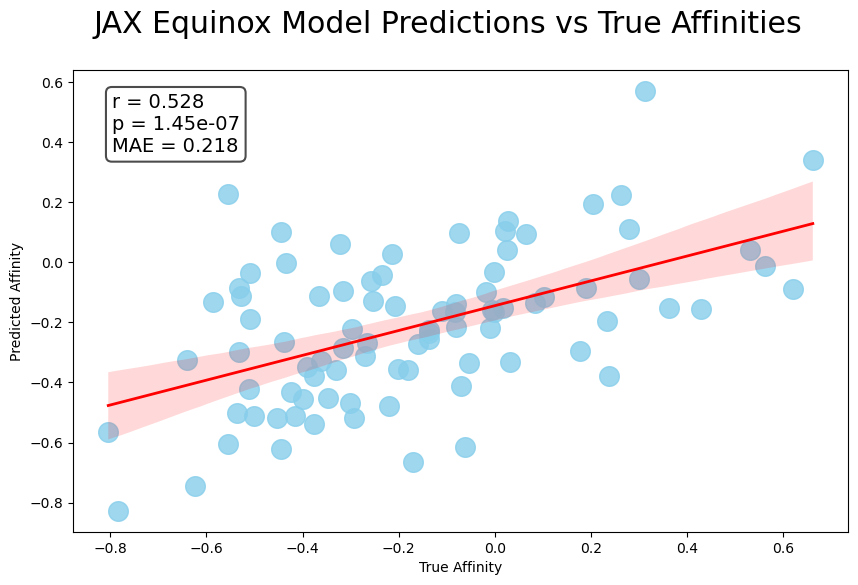

In [15]:
linear_corr_plot(y_val_list, pred_y_list, x_label="True Affinity", y_label="Predicted Affinity",title="JAX Equinox Model Predictions vs True Affinities")

In [16]:
loss_fn = torch.nn.MSELoss()
for param in model_torch.esm2_pept.parameters():
    param.requires_grad_(False)

for param in model_torch.esm2_prot.parameters():
    param.requires_grad_(False)

device = "cuda:1" if torch.cuda.is_available() else "cpu"
device = torch.device(device)
model_torch.to(device)

model_torch.eval()
running_vloss = 0
aux = {"val_loss_steps": [], "predicted_y": [], "true_y": []}
with torch.no_grad():
    for i, val_data in enumerate(torch_loader):
        val_prot, val_pept, val_aff_val = val_data[0]

        id_prot = val_prot["input_ids"].to("cuda:1")
        att_prot = val_prot["attention_mask"].to("cuda:1")

        id_pept = val_pept["input_ids"].to("cuda:1")
        att_pept = val_pept["attention_mask"].to("cuda:1")

        voutputs = model_torch(id_prot, att_prot, id_pept, att_pept)
        vloss = loss_fn(voutputs, torch.tensor(val_aff_val).to("cuda:1"))

        aux["predicted_y"].append(float(val_aff_val))
        aux["true_y"].append(float(voutputs.to("cpu")))
        aux["val_loss_steps"].append(vloss.item())
        print(f"Step Loss - {i}: {vloss.item()}")


Step Loss - 0: 0.0008592500817030668
Step Loss - 1: 0.0007129706209525466
Step Loss - 2: 0.0029169260524213314
Step Loss - 3: 0.0263801459223032
Step Loss - 4: 0.004005810711532831
Step Loss - 5: 0.04317758232355118
Step Loss - 6: 0.5096715688705444
Step Loss - 7: 0.0011245919158682227
Step Loss - 8: 0.48972171545028687
Step Loss - 9: 0.007255942095071077
Step Loss - 10: 0.00022674727370031178
Step Loss - 11: 0.010412877425551414
Step Loss - 12: 0.2610500156879425
Step Loss - 13: 0.2778416574001312
Step Loss - 14: 0.20287416875362396
Step Loss - 15: 0.008526861667633057
Step Loss - 16: 0.015456411056220531
Step Loss - 17: 0.0005083634750917554
Step Loss - 18: 0.0002991447108797729
Step Loss - 19: 0.04232930392026901
Step Loss - 20: 0.014549403451383114
Step Loss - 21: 0.17130295932292938
Step Loss - 22: 0.27491384744644165
Step Loss - 23: 0.19896909594535828
Step Loss - 24: 0.010415316559374332
Step Loss - 25: 0.015803325921297073
Step Loss - 26: 0.014672813937067986
Step Loss - 27: 0.

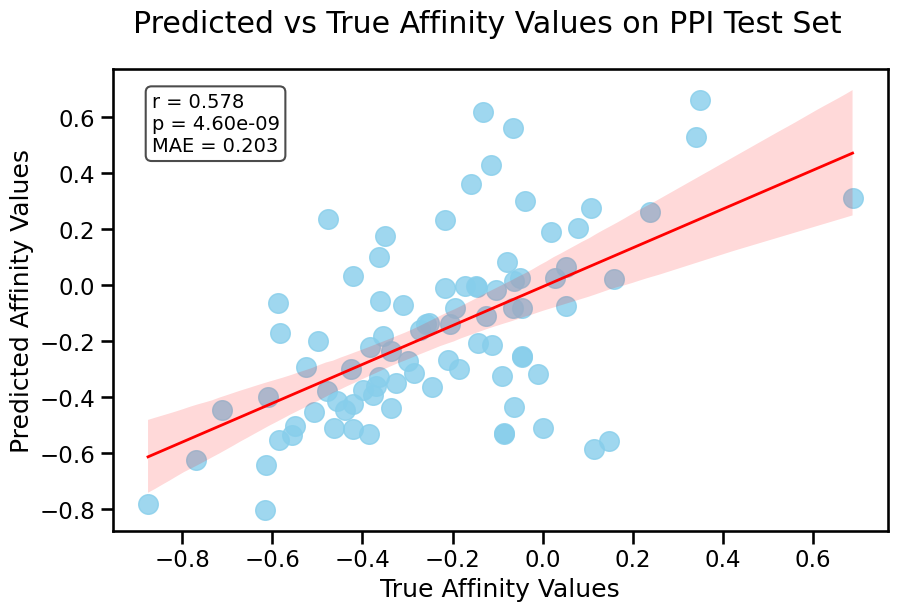

In [17]:
linear_corr_plot(aux['true_y'],aux['predicted_y'],'True Affinity Values','Predicted Affinity Values','Predicted vs True Affinity Values on PPI Test Set')

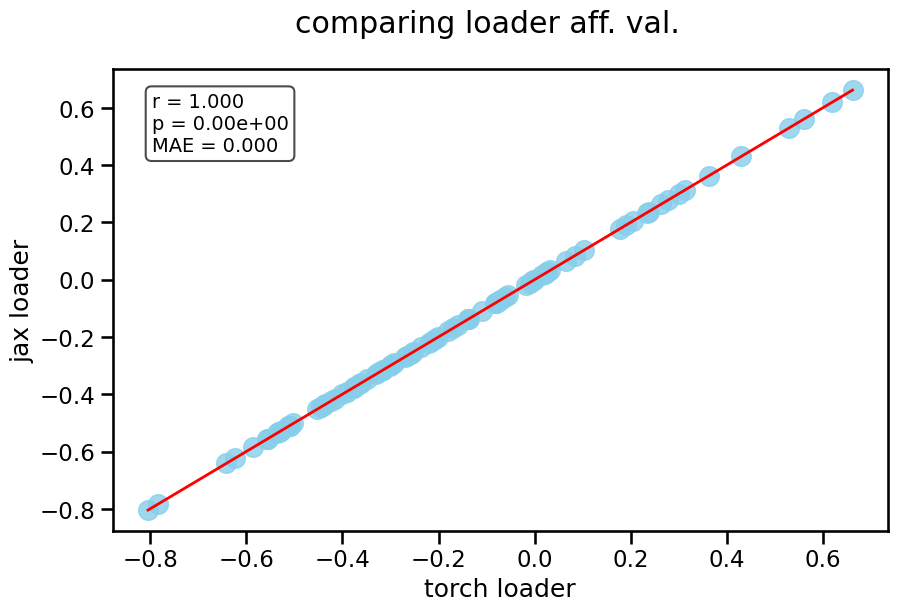

In [18]:
linear_corr_plot(torch_data.aff_Vals,jax_data.aff_Vals,x_label='torch loader',y_label='jax loader',title='comparing loader aff. val.')